# 🛒 E-Commerce Sales Analytics & Recommendation System

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install mlxtend
!pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

## Module 1 — Data Loading & Cleaning

In [3]:
df = pd.read_csv(r"C:\Users\Rishika Sinha\Desktop\RetailData.csv", encoding='latin-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df_copy = df.copy()

In [6]:
print("Shape:", df_copy.shape)
print("DType:", df_copy.dtypes)
print("Missing Values:", df_copy.isnull().sum())
print("nColumns Names:", df_copy.columns.tolist())

Shape: (541909, 8)
DType: InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object
Missing Values: InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
nColumns Names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [7]:
df_copy.dropna(subset=['CustomerID', 'Description'], inplace=True)
df_copy = df_copy[df_copy['Quantity'] > 0]
df_copy = df_copy[df_copy['UnitPrice'] > 0]
df_copy['CustomerID'] = df_copy['CustomerID'].astype(int)
df_copy = df_copy[~df_copy['InvoiceNo'].str.startswith('C')]
df_copy['TotalAmount'] = df_copy['Quantity'] * df_copy['UnitPrice']
df_copy = df_copy[df_copy['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$')]

print("Shape after cleaning:", df_copy.shape)

Shape after cleaning: (396046, 9)


## Module 3 — Exploratory Data Analysis

In [8]:
# Top 10 Customers
df_customers = df_copy.groupby('CustomerID').agg(TotalOrders=('InvoiceNo', 'nunique'),TotalRevenue=('TotalAmount', 'sum'), UniqueProducts=('StockCode', 'nunique')).round(2).sort_values('TotalRevenue', ascending=False).head(10).reset_index()
df_customers

,CustomerID,TotalOrders,TotalRevenue,UniqueProducts
0,14646,72,279138.02,699
1,18102,60,259657.30,150
2,17450,46,194550.79,124
3,16446,2,168472.50,3
4,14911,198,136007.97,1784
5,12415,20,124564.53,443
6,14156,54,116568.98,712
7,17511,31,91062.38,453
8,12346,1,77183.60,1
9,16029,62,72882.09,43


In [9]:
# Top 10 Products
df_products = df_copy.groupby('Description').agg(TotalOrders=('InvoiceNo', 'nunique'),TotalQuantity=('Quantity', 'sum'),TotalRevenue=('TotalAmount', 'sum')).round(2).sort_values('TotalQuantity', ascending=False).head(10).reset_index()
df_products

,Description,TotalOrders,TotalQuantity,TotalRevenue
0,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60
1,MEDIUM CERAMIC TOP STORAGE JAR,195,77916,81416.73
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,472,54415,13586.25
3,JUMBO BAG RED RETROSPOT,1600,46181,85220.78
4,WHITE HANGING HEART T-LIGHT HOLDER,1971,36725,100448.15
5,ASSORTED COLOUR BIRD ORNAMENT,1375,35362,56580.34
6,PACK OF 72 RETROSPOT CAKE CASES,1029,33693,16394.53
7,POPCORN HOLDER,632,30931,23427.71
8,RABBIT NIGHT LIGHT,801,27202,51346.20
9,MINI PAINT SET VINTAGE,325,26076,16039.24


In [10]:
# Revenue by Country
df_revenue = df_copy.groupby('Country').agg(TotalRevenue=('TotalAmount','sum'), TotalQuantity=('Quantity','sum'), UniqueCustomers=('CustomerID', 'nunique')).round(2).sort_values('TotalRevenue', ascending=False).head(10).reset_index()
df_revenue

,Country,TotalRevenue,TotalQuantity,UniqueCustomers
0,United Kingdom,7253457.41,4247211,3916
1,Netherlands,283889.34,200258,9
2,EIRE,256850.31,140100,3
3,Germany,204469.64,117944,94
4,France,183231.23,110526,87
5,Australia,138153.46,83897,9
6,Spain,55725.11,27731,30
7,Switzerland,52370.55,29968,21
8,Japan,37416.37,26016,8
9,Belgium,36855.94,22950,25


In [11]:
df_copy['InvoiceDate'] = pd.to_datetime(df_copy['InvoiceDate'], format='mixed', dayfirst=False)
df_copy['Hour'] = df_copy['InvoiceDate'].dt.hour
df_copy['YearMonth'] = df_copy['InvoiceDate'].dt.to_period('M').astype(str)

In [12]:
# Hourly Orders
df_copy['Hour'] = pd.to_datetime(df_copy['InvoiceDate']).dt.hour
df_hourly = df_copy.groupby('Hour').agg(  TotalOrders=('InvoiceNo', 'nunique'), Revenue=('TotalAmount', 'sum')).round(2).reset_index()
df_hourly

,Hour,TotalOrders,Revenue
0,6,1,4.25
1,7,29,30469.21
2,8,554,276954.98
3,9,1383,828169.12
4,10,2204,1241448.93
5,11,2262,1086438.36
6,12,3117,1363287.91
7,13,2623,1140302.99
8,14,2251,969323.43
9,15,2021,948894.99


In [13]:
# Monthly Revenue
df_copy['YearMonth'] = pd.to_datetime(df_copy['InvoiceDate']).dt.to_period('M').astype(str)
df_monthly = df_copy.groupby('YearMonth').agg(TotalOrders=('InvoiceNo', 'nunique'),MonthlyRevenue=('TotalAmount', 'sum')).round(2).reset_index()
df_monthly

,YearMonth,TotalOrders,MonthlyRevenue
0,2010-12,1393,566425.87
1,2011-01,983,563022.09
2,2011-02,992,442661.77
3,2011-03,1312,583848.85
4,2011-04,1139,454880.16
5,2011-05,1544,659441.65
6,2011-06,1390,653657.61
7,2011-07,1321,590043.80
8,2011-08,1267,635653.99
9,2011-09,1739,939429.96


## Module 4 — Visualisations

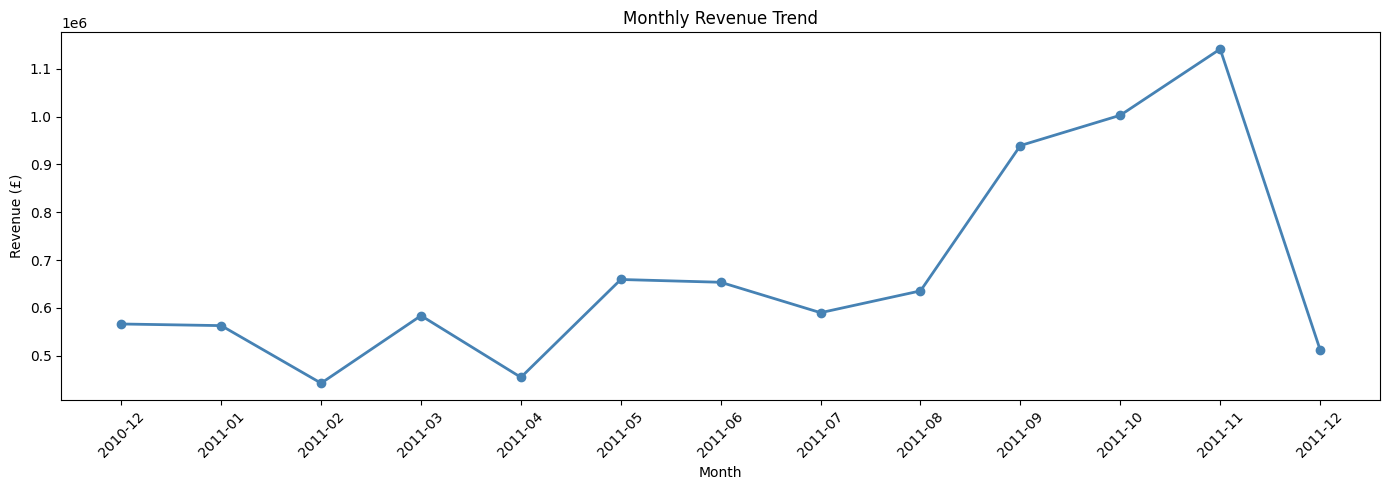

In [14]:
# Monthly Revenue Trends
plt.figure(figsize=(14, 5))
plt.plot(df_monthly['YearMonth'], df_monthly['MonthlyRevenue'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

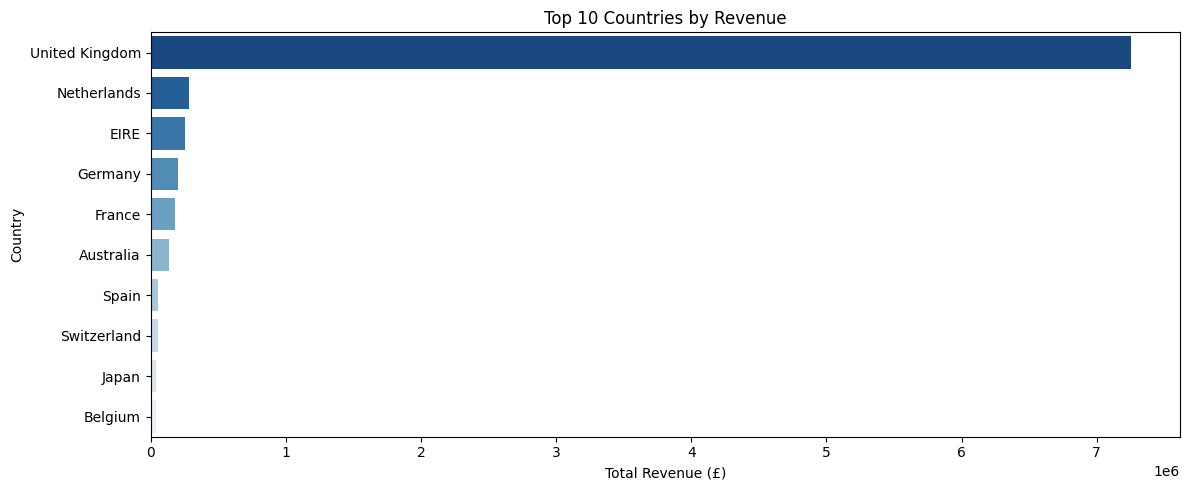

In [15]:
# Top 10 Countries by Revenue
plt.figure(figsize=(12, 5))
sns.barplot(data=df_revenue, x='TotalRevenue', y='Country', palette='Blues_r')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

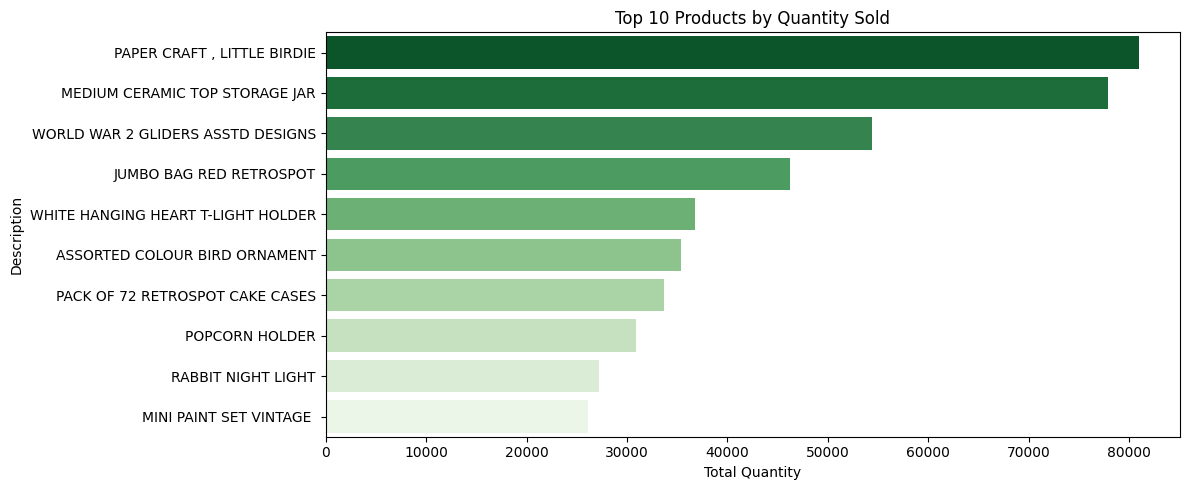

In [16]:
# Top 10 Products by Quantity
plt.figure(figsize=(12, 5))
sns.barplot(data=df_products, x='TotalQuantity', y='Description', palette='Greens_r')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity')
plt.tight_layout()
plt.show()

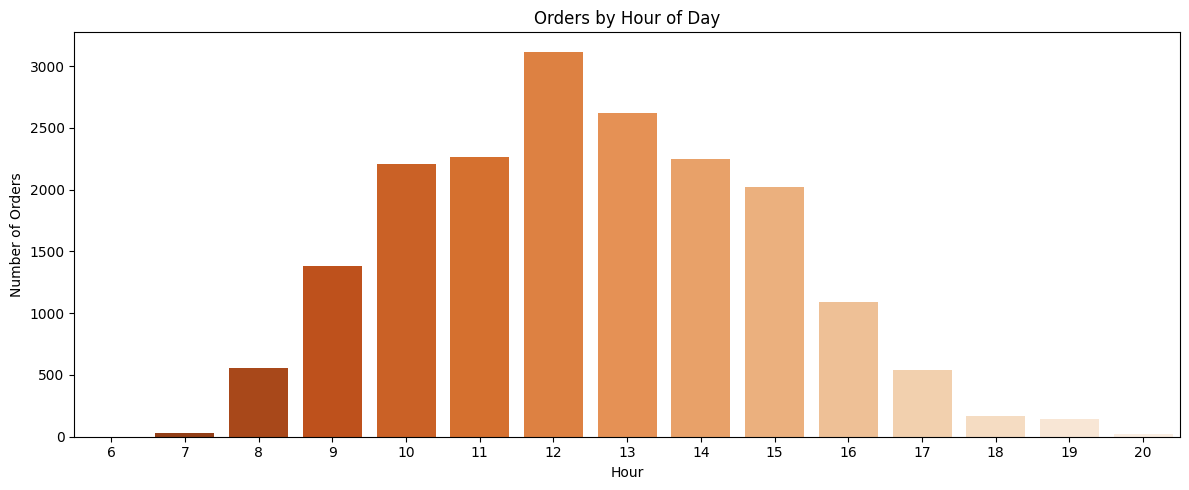

In [17]:
# Orders by Hour
plt.figure(figsize=(12, 5))
sns.barplot(data=df_hourly, x='Hour', y='TotalOrders', palette='Oranges_r')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

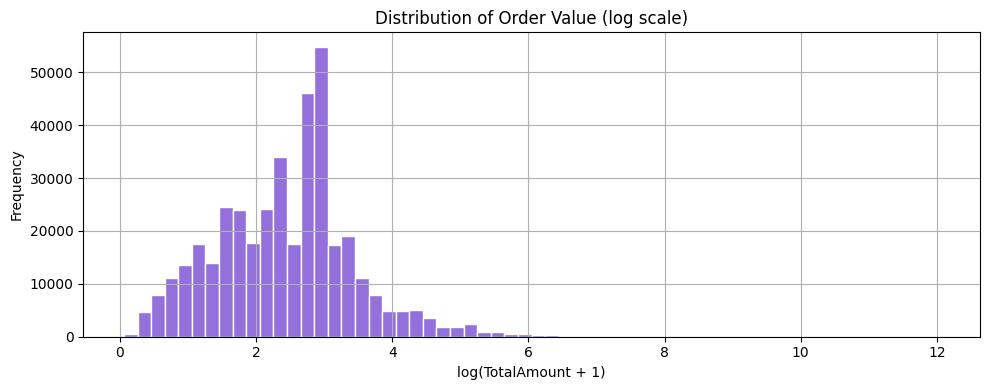

In [18]:
# Revenue Distribution
plt.figure(figsize=(10, 4))
df_copy[df_copy['TotalAmount'] > 0]['TotalAmount'].apply(np.log1p).hist(bins=60, color='mediumpurple', edgecolor='white')
plt.title('Distribution of Order Value (log scale)')
plt.xlabel('log(TotalAmount + 1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Module 5 — RFM Customer Segmentation

In [19]:
# RFM Analysis
last_purchase_date = df_copy['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df_copy.groupby('CustomerID').agg( Recency=('InvoiceDate', lambda x: (last_purchase_date - x.max()).days),
                                         Frequency=('InvoiceNo', 'nunique'),
                                         Monetary=('TotalAmount', 'sum')).reset_index()
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

def segment(row):
    r, f = row['R_Score'], row['F_Score']
    if r >= 4 and f >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4: return 'Recent Customers'
    elif f >= 4: return 'At Risk'
    else: return 'Lost'
rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,12346,326,1,77183.60,1,1,5,Lost
1,12347,2,7,4310.00,5,5,5,Champions
2,12348,75,4,1437.24,2,4,4,At Risk
3,12349,19,1,1457.55,4,1,4,Recent Customers
4,12350,310,1,294.40,1,1,2,Lost
5,12352,36,7,1385.74,3,5,4,Loyal Customers
6,12353,204,1,89.00,1,1,1,Lost
7,12354,232,1,1079.40,1,1,4,Lost
8,12355,214,1,459.40,1,1,2,Lost
9,12356,23,3,2487.43,4,3,5,Loyal Customers


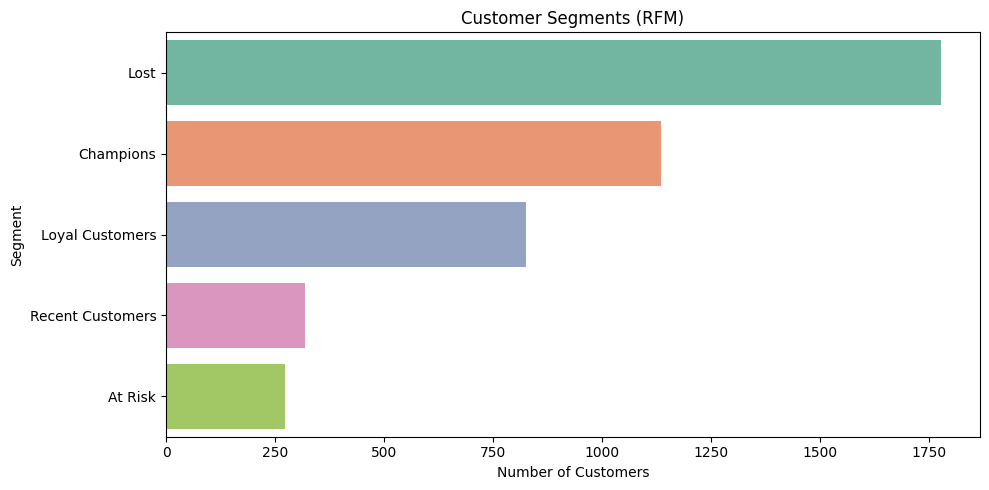

In [20]:
# RFM Segment Distribution
plt.figure(figsize=(10, 5))
seg_counts = rfm['Segment'].value_counts()
sns.barplot(x=seg_counts.values, y=seg_counts.index, palette='Set2')
plt.title('Customer Segments (RFM)')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

## Module 6 — Time Series Forecasting (ARIMA)

In [21]:
# Time-Series Forecasting ARIMA
t_s = df_monthly.set_index('YearMonth')['MonthlyRevenue']
t_s.index = pd.PeriodIndex(t_s.index, freq='M')
t_s = t_s.asfreq('M')

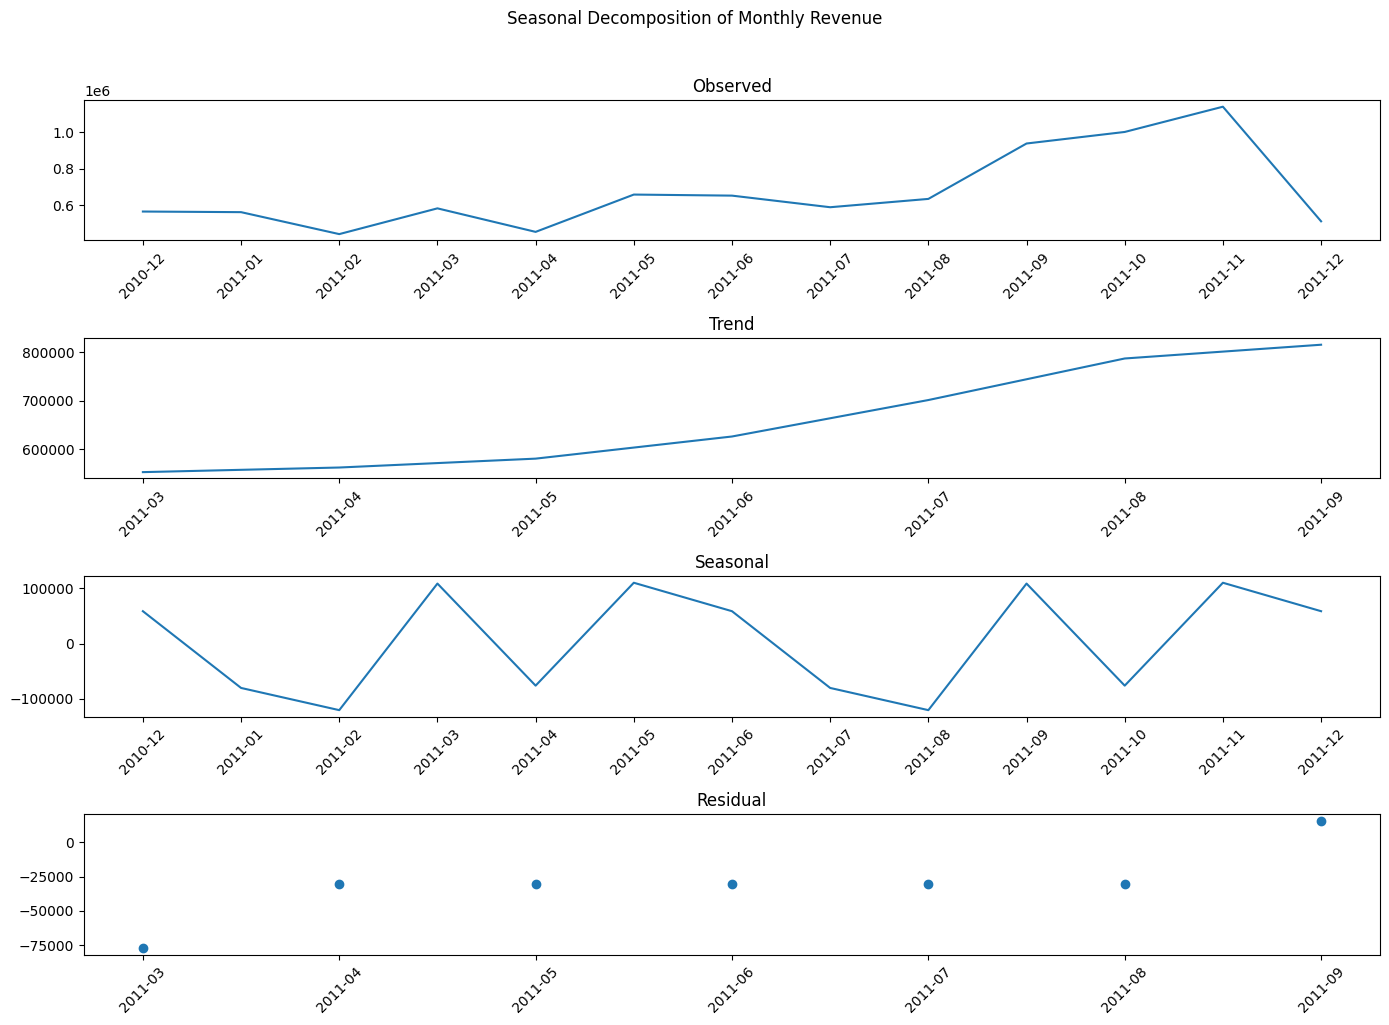

In [22]:
# Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

t_s = df_monthly.set_index('YearMonth')['MonthlyRevenue'].copy()

# Decompose
decomp = seasonal_decompose(t_s.values, model='additive', period=6)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(t_s.index, decomp.observed); axes[0].set_title('Observed'); axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(t_s.index, decomp.trend); axes[1].set_title('Trend'); axes[1].tick_params(axis='x', rotation=45)
axes[2].plot(t_s.index, decomp.seasonal); axes[2].set_title('Seasonal'); axes[2].tick_params(axis='x', rotation=45)
axes[3].plot(t_s.index, decomp.resid, marker='o', linestyle='none'); axes[3].set_title('Residual'); axes[3].tick_params(axis='x', rotation=45)
plt.suptitle('Seasonal Decomposition of Monthly Revenue', y=1.02)
plt.tight_layout()
plt.show()

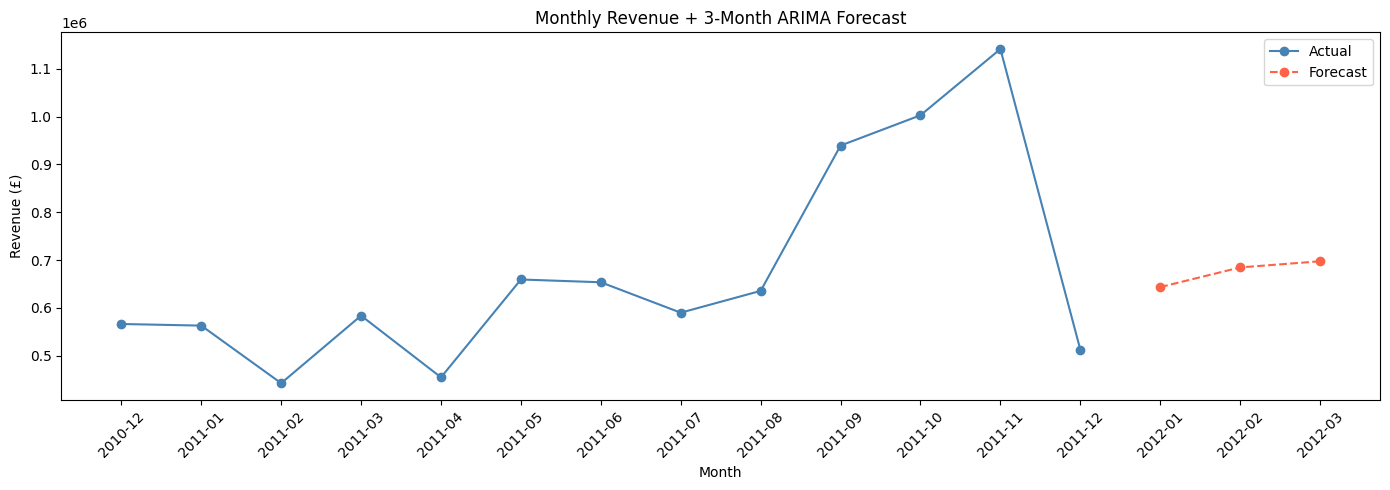


Forecast:
  2012-01: £643,595.66
  2012-02: £684,651.64
  2012-03: £697,539.59


In [23]:
# ARIMA Forecast
model = ARIMA(t_s.values, order=(1,1,1))
result = model.fit()
forecast = result.forecast(steps=3)

forecast_index = ['2012-01', '2012-02', '2012-03']
all_index = list(t_s.index) + forecast_index

plt.figure(figsize=(14, 5))
plt.plot(t_s.index, t_s.values, marker='o', color='steelblue', label='Actual')
plt.plot(forecast_index, forecast, marker='o', linestyle='--', color='tomato', label='Forecast')
plt.xticks(rotation=45)
plt.title('Monthly Revenue + 3-Month ARIMA Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nForecast:")
for month, val in zip(forecast_index, forecast):
    print(f"  {month}: £{val:,.2f}")

## Module 7 — Market Basket Analysis

In [31]:
# Top 100 products
top_products = df_copy[df_copy['Country'] == 'United Kingdom'].groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(100).index

# Filter basket to only those products
uk_df = df_copy[(df_copy['Country'] == 'United Kingdom') & (df_copy['Description'].isin(top_products))]

basket = uk_df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = basket.map(lambda x: 1 if x > 0 else 0)

print(f"Basket shape: {basket.shape}")

frequent_items = apriori(basket, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_items, metric='lift', min_threshold=2.0)
rules = rules.sort_values('lift', ascending=False)

print(f"Frequent itemsets: {len(frequent_items)}")
print(f"Association rules: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Basket shape: (13123, 100)
Frequent itemsets: 365
Association rules: 786


,antecedents,consequents,support,confidence,lift
340,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.022861,0.748130,22.569438
341,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.022861,0.689655,22.569438
361,"frozenset({GIN + TONIC DIET METAL SIGN, PLEASE...",frozenset({COOK WITH WINE METAL SIGN }),0.011354,0.647826,14.967292
364,frozenset({COOK WITH WINE METAL SIGN }),"frozenset({GIN + TONIC DIET METAL SIGN, PLEASE...",0.011354,0.262324,14.967292
498,"frozenset({JUMBO BAG RED RETROSPOT, JUMBO BAG ...",frozenset({JUMBO BAG SCANDINAVIAN BLUE PAISLEY}),0.010973,0.476821,14.757841
503,frozenset({JUMBO BAG SCANDINAVIAN BLUE PAISLEY}),"frozenset({JUMBO BAG RED RETROSPOT, JUMBO BAG ...",0.010973,0.339623,14.757841
368,"frozenset({HAND OVER THE CHOCOLATE SIGN , PL...",frozenset({COOK WITH WINE METAL SIGN }),0.010973,0.626087,14.465034
369,frozenset({COOK WITH WINE METAL SIGN }),"frozenset({HAND OVER THE CHOCOLATE SIGN , PL...",0.010973,0.253521,14.465034
737,"frozenset({LUNCH BAG BLACK SKULL., LUNCH BAG ...","frozenset({LUNCH BAG SUKI DESIGN , LUNCH BAG P...",0.011126,0.363184,14.312507
736,"frozenset({LUNCH BAG SUKI DESIGN , LUNCH BAG P...","frozenset({LUNCH BAG BLACK SKULL., LUNCH BAG ...",0.011126,0.438438,14.312507


In [32]:
frequent_items = apriori(basket, min_support=0.02, use_colnames=True, low_memory=True)
rules = association_rules(frequent_items, metric='lift', min_threshold=2.0)
rules = rules.sort_values('lift', ascending=False)

print(f"Frequent itemsets: {len(frequent_items)}")
print(f"Association rules: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Frequent itemsets: 124
Association rules: 82


,antecedents,consequents,support,confidence,lift
74,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.022861,0.748130,22.569438
75,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.022861,0.689655,22.569438
3,frozenset({COOK WITH WINE METAL SIGN }),frozenset({GIN + TONIC DIET METAL SIGN}),0.020117,0.464789,9.650985
2,frozenset({GIN + TONIC DIET METAL SIGN}),frozenset({COOK WITH WINE METAL SIGN }),0.020117,0.417722,9.650985
76,"frozenset({LUNCH BAG BLACK SKULL., LUNCH BAG ...",frozenset({LUNCH BAG PINK POLKADOT}),0.022327,0.605372,9.368273
81,frozenset({LUNCH BAG PINK POLKADOT}),"frozenset({LUNCH BAG BLACK SKULL., LUNCH BAG ...",0.022327,0.345519,9.368273
67,frozenset({PAPER CHAIN KIT VINTAGE CHRISTMAS}),frozenset({PAPER CHAIN KIT 50'S CHRISTMAS }),0.033300,0.645495,8.963840
66,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS }),frozenset({PAPER CHAIN KIT VINTAGE CHRISTMAS}),0.033300,0.462434,8.963840
79,frozenset({LUNCH BAG BLACK SKULL.}),"frozenset({LUNCH BAG RED RETROSPOT, LUNCH BAG ...",0.022327,0.294177,8.196350
78,"frozenset({LUNCH BAG RED RETROSPOT, LUNCH BAG ...",frozenset({LUNCH BAG BLACK SKULL.}),0.022327,0.622081,8.196350


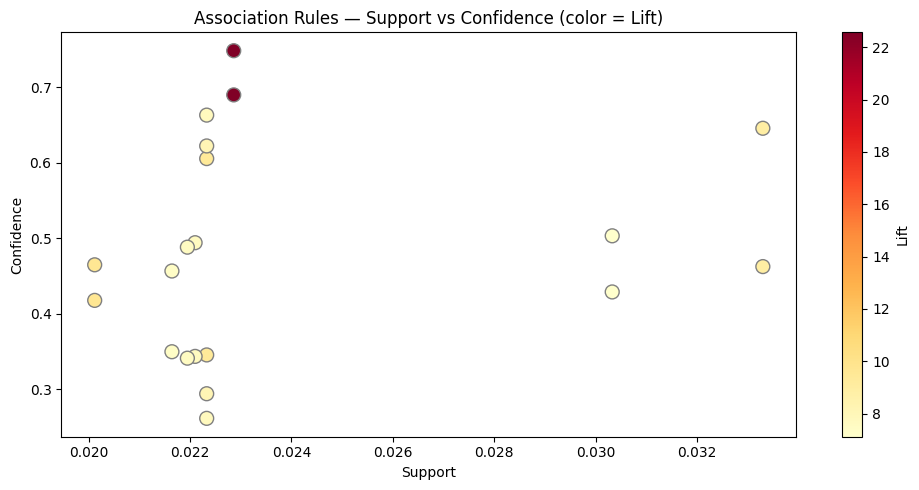

In [33]:
plt.figure(figsize=(10, 5))
top_rules = rules.head(20)
plt.scatter(top_rules['support'], top_rules['confidence'],  c=top_rules['lift'], cmap='YlOrRd', s=100, edgecolors='gray')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules — Support vs Confidence (color = Lift)')
plt.tight_layout()
plt.show()

## Module 8 — Recommendation System

In [34]:
# Content Based 

def recommend(product_name, rules_df, n=5):
    mask = rules_df['antecedents'].apply(lambda x: product_name in str(x))
    results = rules_df[mask][['consequents', 'confidence', 'lift']].head(n)
    results = results.copy()
    results['consequents'] = results['consequents'].apply(lambda x: list(x)[0])
    results.columns = ['Recommended Product', 'Confidence', 'Lift']
    return results.reset_index(drop=True)

recommend('WOODEN STAR CHRISTMAS SCANDINAVIAN', rules)

,Recommended Product,Confidence,Lift
0,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.74813,22.569438


In [42]:
# Collaborative filtering 
from sklearn.metrics.pairwise import cosine_similarity

customer_matrix = df_copy[df_copy['Country'] == 'United Kingdom'].groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack().fillna(0)

similarity = cosine_similarity(customer_matrix)
sim_df = pd.DataFrame(similarity,  index=customer_matrix.index, columns=customer_matrix.index)

def recommend_for_customer(customer_id, n=5):
    if customer_id not in sim_df.index:
        return "Customer not found"
    similar_customers = sim_df[customer_id].sort_values(ascending=False)[1:6].index
    already_bought = set(customer_matrix.loc[customer_id][customer_matrix.loc[customer_id] > 0].index)
    recommendations = customer_matrix.loc[similar_customers].sum().sort_values(ascending=False)
    recommendations = recommendations[~recommendations.index.isin(already_bought)].head(n)
    return pd.DataFrame({
        'Recommended Product': recommendations.index, 
        'Score': recommendations.values
    }).reset_index(drop=True)


recommend_for_customer(12346)

,Recommended Product,Score
0,SMALL CERAMIC TOP STORAGE JAR,106.0
1,JAM JAR WITH PINK LID,72.0
2,PARTY BUNTING,62.0
3,RED PUDDING SPOON,48.0
4,WOODEN HEART CHRISTMAS SCANDINAVIAN,48.0


## Conclusion

This project successfully built an end-to-end e-commerce analytics pipeline on the UCI Online Retail dataset (396,046 transactions across 13 months):

- RFM segmentation classified 4,334 customers — Champions (largest group), followed by Loyal and Lost segments
- ARIMA(1,1,1) forecasted 3-month revenue recovery (£643K → £697K) after a seasonal December dip
- Apriori algorithm generated 82 association rules with a maximum lift of 22.5 between co-purchased Christmas items
- Collaborative filtering and content-based recommendation systems successfully personalised product suggestions per customer